# Matrice di confusione

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random as rn

k, eps = 15, .9
y_test = [0,1]*k
test_pred = [y if rn.random() <= eps else (y+1)%2 for y in y_test]


cm = confusion_matrix(y_test, test_pred)

print("Matrice di confusione:")
print(cm)

Matrice di confusione:
[[13  2]
 [ 1 14]]


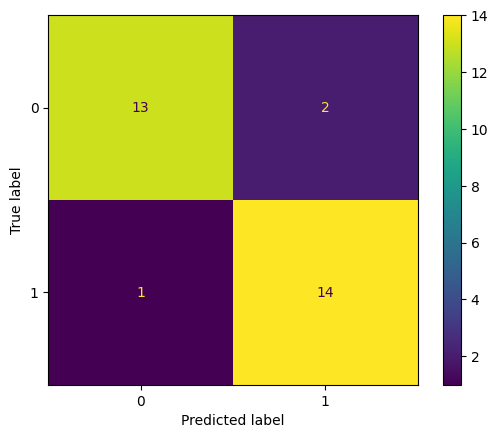

In [9]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [3]:
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(tn, fp, fn, tp)

14 1 0 15


## Precision e recall

In [4]:
precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)


Precision: 0.9375
Recall: 1.0


- alta precision + bassa recall → il modello è “prudente” ma perde molti positivi
- bassa precision + alta recall → il modello trova molti positivi ma con molti errori
- F1 alto → buon equilibrio tra le due

## F1 score

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$


- assume valore massimo pari a 1 quando precision e recall sono entrambe perfette,
- è basso quando uno dei due valori è basso,
- penalizza fortemente gli squilibri tra precision e recall (più della media aritmetica).

Utile quando:
- le classi sono sbilanciate,
- i falsi positivi e i falsi negativi hanno importanza simile

In [10]:
F1 = 2*(precision*recall)/(precision+recall)
print(F1)

0.967741935483871


## ROC Curve (Receiver Operating Characteristic)

La **ROC curve (Receiver Operating Characteristic)** è una rappresentazione grafica che descrive le prestazioni di un classificatore binario al variare della soglia decisionale.

Le metriche che evidenzia sono le segueti

- **True Positive Rate (TPR)**: percentuale dei positivi classificati come positivi
$$
TPR = \frac{TP}{TP+FN}
$$

- **False Positive Rate (FPR)**: percentuale dei negativi classificati come positivi
$$
FPR = \frac{FP}{FP+TN}
$$

Tipicamente i modelli di classificazione calcolano un valore compreso tra 0 e 1 interpretato come la probabilità che il campione sia positivo. La classe è stabilita applicando una soglia, tipicamente 0.5, a questo valore.

Ad ogni soglia corrisponde una coppia $(FPR, TPR)$. La ROC curve è il luogo dei punti $(FPR, TPR)$ ottenuti variando la soglia del classificatore.

Quindi se nella ROC compare un punto in posizione $(x,y)$ allora esiste una soglia $t$ tale che il classificatore ha:
- FPR = $x$
- TPR = $y$

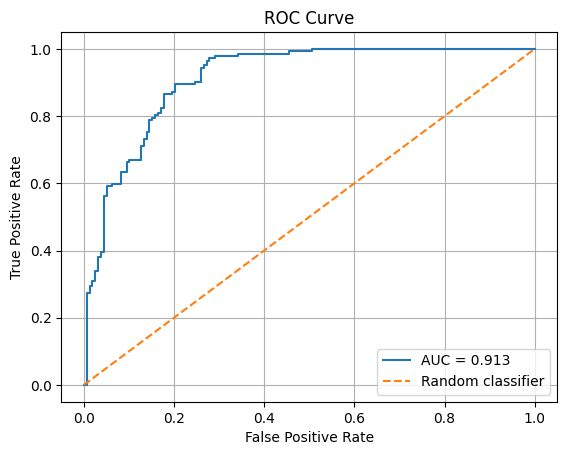

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Dataset sintetico
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    random_state=42
)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Modello (probabilistico)
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Probabilità della classe positiva
y_scores = model.predict_proba(X_test)[:, 1]

# 5. ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# 6. Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

Per un classificatore perfetto esiste una soglia per cui ha pochi falsi positivi (FPR vicino a 0) e tanti veri positivi (TRP vicino a 1). Quindi più una curva occupa l'ancolo in alto a sinistra, più il classificatore è valido.

Se la curva è la diagonale, allora per ogni soglia, se questa garantisce un basso grado di falsi positivi allora è basso anche il grado di veri positivi.

Maggiore è l'area sotto la curva (**AUC**), migliore è il classificatore. 

# Classificazione di Dataset Sbilanciati con SVM

Si vuole affrontare il problema della classificazione di dataset sbilanciati, costituiti da due classi:

- classe `0` (maggioritaria),
- classe `1` (minoritaria).

Si consideri un dataset sintetico con forte sbilanciamento (ad esempio 95% dei campioni appartenenti alla classe `0` e 5% alla classe `1`).



---

## 1. Bilanciamento dei dati per training e validazione

1. Generare un dataset sintetico di classificazione binaria.

2. Suddividere il dataset in:
   - training set,
   - test set.

3. **A partire dal training set, estrarre inizialmente un sottoinsieme bilanciato**, selezionando casualmente lo stesso numero di campioni per ciascuna classe, pari al numero di campioni della classe minoritaria.

4. Applicare una validazione incrociata stratificata a `K` fold sul training set bilanciato ottenuto al punto precedente.

5. Al termine della cross-validation, addestrare il modello finale su un training set bilanciato (ottenuto come al punto 3) e valutarlo su un test set non bilanciato, mantenendo la distribuzione originale delle classi, al fine di ottenere una stima realistica delle prestazioni del modello in condizioni di sbilanciamento.

6. Valutare il modello con una metrica appropriata. 



----

## 2. Modifica dell'implementazione della SVM


Si consideri la formulazione soft-margin della SVM:

$$
\frac{1}{2}\|w\|^2
+
C\sum_{i=1}^{N}\xi_i
$$

Modificare l'implementazione sostituendo il parametro globale `C` con un parametro specifico per ciascun campione:

$$
C_i = C \cdot v_{i}
$$

dove:

- $v_{i}$ è il peso associato alla classe del campione $i$,

I pesi di classe sono definiti come inversamente proporzionali alla frequenza delle classi nel training set:

$$
v_c = \frac{n}{2n_c}
$$

dove:

- $n$ è il numero totale di campioni del training set,
- $n_c$ è il numero di campioni appartenenti alla classe $c$.

In questo modo:

- la classe maggioritaria riceve un peso minore;
- la classe minoritaria riceve un peso maggiore;
- gli errori sui campioni della classe minoritaria vengono penalizzati maggiormente.


---

## 3. Valutazione sperimentale

Implementare la nuova versione della SVM e ripetere la stessa procedura di cross-validation e test descritta al punto 1, mantenendo:

- training set sbilanciato;
- validation set sbilanciato;
- test set sbilanciato.

Confrontare i risultati ottenuti con quelli della strategia basata sul bilanciamento esplicito dei dati.




---

## 4. Discussione finale

Confrontare le due strategie:

1. bilanciamento esplicito di training e validation set;
2. modifica della funzione obiettivo tramite pesi `C_i`.
3. Discutere vantaggi e svantaggi di ciascun approccio e indicare in quali situazioni pratiche uno dei due metodi possa essere preferibile all'altro.